# 06. 기본 모델링

`train_eda_fixed.csv`만 사용한다. 시간순 검증 데이터로 baseline 모델과 stacking을 비교하고, test 데이터는 최종 모델 확정 전까지 사용하지 않는다.

In [14]:
from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 노트북 출력에서 반복 경고는 숨기고, 그래프 스타일은 공통으로 맞춘다.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


def setup_korean_font():
    def apply_font(font_name, source):
        plt.rcParams['font.family'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid', rc={
            'font.family': [font_name],
            'axes.unicode_minus': False,
        })
        print(f'한글 폰트 설정: {font_name} ({source})')
        return font_name

    # 저장소에 포함한 폰트를 먼저 사용해 OS/Colab 환경 차이 없이 한글 깨짐을 방지한다.
    local_font_paths = [
        Path('assets/fonts/NanumGothic-Regular.ttf'),
        Path('../assets/fonts/NanumGothic-Regular.ttf'),
    ]
    for font_path in local_font_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            return apply_font(font_name, font_path)

    # 로컬 폰트가 없을 때는 운영체제에 설치된 한글 폰트를 사용한다.
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            return apply_font(font_name, 'system')

    # 폰트가 없을 때도 마이너스 기호 깨짐은 방지한다.
    plt.rcParams['axes.unicode_minus'] = False
    print('사용 가능한 한글 폰트를 찾지 못했다. assets/fonts/NanumGothic-Regular.ttf 파일을 확인한다.')
    return None


setup_korean_font()

# 모든 실험에서 같은 난수 시드를 사용해 결과 재현성을 맞춘다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

한글 폰트 설정: NanumGothic (../assets/fonts/NanumGothic-Regular.ttf)


## 데이터 로드 및 시간순 검증 분리

In [15]:
# 노트북 폴더와 프로젝트 루트 양쪽 실행을 모두 지원한다.
DATA_DIR = Path('../data')
if not (DATA_DIR / 'train_eda_fixed.csv').exists():
    DATA_DIR = Path('data')

TRAIN_PATH = DATA_DIR / 'train_eda_fixed.csv'
DATE_COL = 'baseline_create_date'
TARGET_COL = 'target'
VALID_SIZE = 0.2

# 모델 선택 단계에서는 test 데이터를 읽지 않고 train 데이터만 사용한다.
raw = pd.read_csv(TRAIN_PATH)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])
raw = raw.sort_values(DATE_COL).reset_index(drop=True)

# 시계열성을 고려해 과거 80%를 학습, 이후 20%를 검증 데이터로 사용한다.
split_idx = int(len(raw) * (1 - VALID_SIZE))
train_inner_raw = raw.iloc[:split_idx].copy()
valid_raw = raw.iloc[split_idx:].copy()

print(f'전체 데이터: {raw.shape}')
print(f'train_inner: {train_inner_raw.shape} | {train_inner_raw[DATE_COL].min().date()} ~ {train_inner_raw[DATE_COL].max().date()}')
print(f'validation : {valid_raw.shape} | {valid_raw[DATE_COL].min().date()} ~ {valid_raw[DATE_COL].max().date()}')
display(pd.DataFrame({
    'train_inner': train_inner_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
    'validation': valid_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
}))

전체 데이터: (31326, 49)
train_inner: (25060, 49) | 2018-12-14 ~ 2019-09-16
validation : (6266, 49) | 2019-09-16 ~ 2019-11-18


,train_inner,validation
target,,
0,0.932243,0.938398
1,0.067757,0.061602


## 공통 피처 구성

06/07/08에서 같은 제거 컬럼과 같은 Pipeline 전처리를 사용한다. 비교 공정성을 위해 상관계수 기반 필터링은 제거했다.

In [16]:
# target을 직접 설명하거나 운영 시점에 알 수 없는 컬럼은 모델 입력에서 제외한다.
DROP_COLS = [
    'cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date',
    'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter',
    'business_days_late',
]


def split_xy(df):
    # 같은 컬럼 규칙으로 feature와 target을 분리한다.
    drop_cols = [col for col in DROP_COLS if col in df.columns]
    model_df = df.drop(columns=drop_cols).copy()
    y = model_df[TARGET_COL].astype(int)
    X = model_df.drop(columns=TARGET_COL)
    return X, y


X_train, y_train = split_xy(train_inner_raw)
X_valid, y_valid = split_xy(valid_raw)

# 전처리기는 train split에서 확인한 컬럼 목록을 기준으로 구성한다.
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f'사용 피처 수: {X_train.shape[1]}')
print(f'수치형: {len(num_cols)} | 범주형: {len(cat_cols)}')
print('제거 컬럼:', [col for col in DROP_COLS if col in raw.columns])

사용 피처 수: 37
수치형: 34 | 범주형: 3
제거 컬럼: ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter', 'business_days_late']


In [17]:
def make_preprocessor(scale_numeric=False):
    # 수치형은 median imputation, 범주형은 최빈값 imputation 후 one-hot encoding을 적용한다.
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        # Logistic Regression처럼 scale에 민감한 모델에만 StandardScaler를 적용한다.
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), num_cols),
            ('cat', Pipeline(categorical_steps), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def make_model_pipeline(model, scale_numeric=False):
    # 전처리와 모델을 하나의 Pipeline으로 묶어 검증 과정의 전처리 누수를 막는다.
    return Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=scale_numeric)),
        ('model', model),
    ])


def evaluate_predictions(name, y_true, pred, pred_proba=None):
    # 모델 선택에 필요한 지표와 confusion matrix는 모두 validation 기준으로 출력한다.
    print('=' * 70)
    print(f'[{name}] 검증 성능')
    print(f'Accuracy : {accuracy_score(y_true, pred):.4f}')
    print(f'Macro F1 : {f1_score(y_true, pred, average="macro"):.4f}')
    if pred_proba is not None:
        print(f'ROC AUC  : {roc_auc_score(y_true, pred_proba):.4f}')
    print()
    print('분류 리포트')
    print(classification_report(y_true, pred, labels=[0, 1]))
    print('Confusion matrix')  # 행: 실제값, 열: 예측값, labels=[0, 1] 순서
    print(confusion_matrix(y_true, pred, labels=[0, 1]))


def evaluate_model(name, pipeline):
    # train_inner로 학습하고 validation으로만 성능을 확인한다.
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    pred = fitted.predict(X_valid)
    pred_proba = fitted.predict_proba(X_valid)[:, 1]
    evaluate_predictions(name, y_valid, pred, pred_proba)
    return {
        'model': name,
        'accuracy': accuracy_score(y_valid, pred),
        'macro_f1': f1_score(y_valid, pred, average='macro'),
        'roc_auc': roc_auc_score(y_valid, pred_proba),
        'fitted_model': fitted,
        'valid_proba': pred_proba,
    }


def find_best_threshold(y_true, pred_proba):
    # threshold도 test가 아니라 validation 예측 확률로만 선택한다.
    rows = []
    for threshold in np.arange(0.01, 0.91, 0.01):
        pred = (pred_proba >= threshold).astype(int)
        rows.append({'threshold': threshold, 'macro_f1': f1_score(y_true, pred, average='macro')})
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)

## 기본 모델 성능 비교

In [18]:
# 비교 대상 모델은 같은 feature set과 같은 validation split을 사용한다.
baseline_models = {
    'Logistic Regression': make_model_pipeline(
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED), True),
    'Random Forest': make_model_pipeline(
        RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1), False),
    'XGBoost': make_model_pipeline(
        xgb.XGBClassifier(n_estimators=300, random_state=SEED, seed=SEED, eval_metric='logloss', n_jobs=-1), False),
    'LightGBM': make_model_pipeline(
        lgb.LGBMClassifier(n_estimators=300, random_state=SEED, seed=SEED, verbose=-1, n_jobs=-1), False),
}

baseline_results = [evaluate_model(name, model) for name, model in baseline_models.items()]

# 모델 선택용 요약표이다. test 성능은 포함하지 않는다.
summary_df = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['fitted_model', 'valid_proba']}
    for row in baseline_results
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(summary_df)

[Logistic Regression] 검증 성능
Accuracy : 0.8924
Macro F1 : 0.6876
ROC AUC  : 0.8801

분류 리포트
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5880
           1       0.32      0.67      0.43       386

    accuracy                           0.89      6266
   macro avg       0.65      0.79      0.69      6266
weighted avg       0.94      0.89      0.91      6266

Confusion matrix
[[5333  547]
 [ 127  259]]
[Random Forest] 검증 성능
Accuracy : 0.9611
Macro F1 : 0.7830
ROC AUC  : 0.8647

분류 리포트
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5880
           1       0.85      0.45      0.59       386

    accuracy                           0.96      6266
   macro avg       0.91      0.72      0.78      6266
weighted avg       0.96      0.96      0.96      6266

Confusion matrix
[[5849   31]
 [ 213  173]]
[XGBoost] 검증 성능
Accuracy : 0.9580
Macro F1 : 0.7812
ROC AUC  : 0.8624

분류 리포트
      

,model,accuracy,macro_f1,roc_auc
0,LightGBM,0.957389,0.783064,0.875609
1,Random Forest,0.961060,0.783004,0.864699
2,XGBoost,0.958027,0.781208,0.862443
3,Logistic Regression,0.892435,0.687564,0.880058


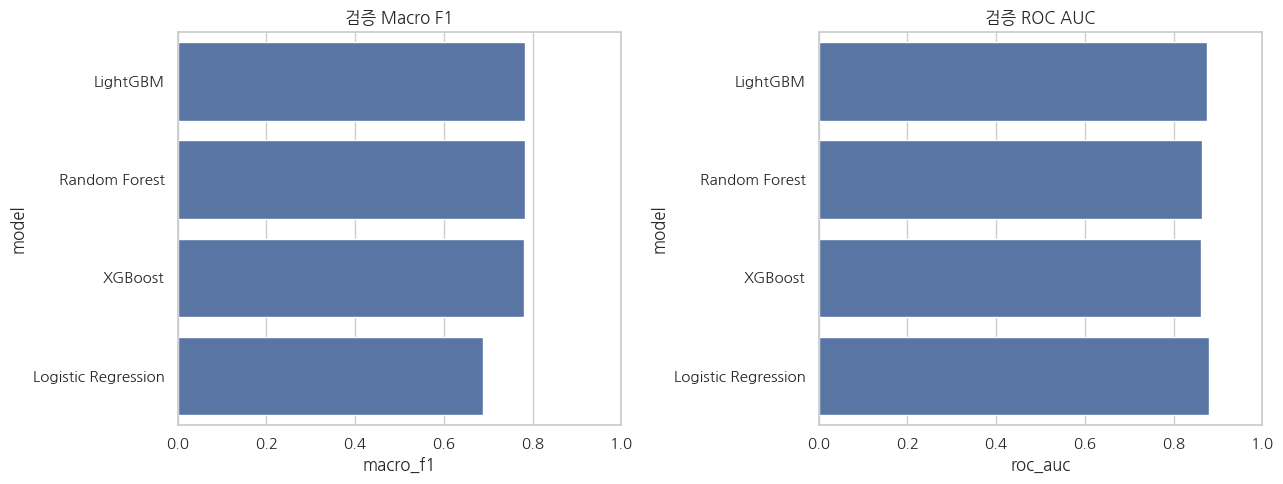

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=summary_df, x='macro_f1', y='model', ax=axes[0])
axes[0].set_title('검증 Macro F1')
axes[0].set_xlim(0, 1)
sns.barplot(data=summary_df, x='roc_auc', y='model', ax=axes[1])
axes[1].set_title('검증 ROC AUC')
axes[1].set_xlim(0, 1)
plt.tight_layout()

## Stacking 기본 모델

In [20]:
def stacking_predict(base_model_dict):
    # base model의 OOF 확률을 meta model 입력으로 사용한다.
    # CV는 train_inner 안에서만 수행한다. validation은 최종 선택용으로만 남겨둔다.
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((len(X_train), len(base_model_dict)))
    valid_preds = np.zeros((len(X_valid), len(base_model_dict)))
    fitted_base_models = {}
    X = X_train.reset_index(drop=True)
    y = y_train.reset_index(drop=True)

    for model_idx, (model_name, model) in enumerate(base_model_dict.items()):
        valid_fold_preds = np.zeros((len(X_valid), skf.n_splits))
        print(f'[{model_name}] CV 시작')
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            fold_model = clone(model)
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            fold_model.fit(X_tr, y_tr)

            oof_preds[val_idx, model_idx] = fold_model.predict_proba(X_val)[:, 1]
            valid_fold_preds[:, fold - 1] = fold_model.predict_proba(X_valid)[:, 1]
            fold_pred = (oof_preds[val_idx, model_idx] >= 0.5).astype(int)
            print(f'  Fold {fold} macro F1: {f1_score(y_val, fold_pred, average="macro"):.4f}')

        valid_preds[:, model_idx] = valid_fold_preds.mean(axis=1)

        # 피처 중요도와 이후 해석을 위해 전체 train_inner로 최종 base model을 다시 학습한다.
        final_base = clone(model)
        final_base.fit(X_train, y_train)
        fitted_base_models[model_name] = final_base

    meta_model = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=3000, random_state=SEED)
    meta_model.fit(oof_preds, y_train)
    final_pred = meta_model.predict(valid_preds)
    final_proba = meta_model.predict_proba(valid_preds)[:, 1]

    evaluate_predictions('Stacking (LR+RF+XGB+LGBM)', y_valid, final_pred, final_proba)
    return meta_model, fitted_base_models, final_proba, final_pred


meta_model, fitted_base_models, stacking_valid_proba, stacking_valid_pred = stacking_predict(baseline_models)

[Logistic Regression] CV 시작
  Fold 1 macro F1: 0.6943
  Fold 2 macro F1: 0.7149
  Fold 3 macro F1: 0.7013
  Fold 4 macro F1: 0.6817
  Fold 5 macro F1: 0.6988
[Random Forest] CV 시작
  Fold 1 macro F1: 0.7986
  Fold 2 macro F1: 0.7873
  Fold 3 macro F1: 0.7857
  Fold 4 macro F1: 0.7979
  Fold 5 macro F1: 0.8192
[XGBoost] CV 시작
  Fold 1 macro F1: 0.8030
  Fold 2 macro F1: 0.7880
  Fold 3 macro F1: 0.7941
  Fold 4 macro F1: 0.7861
  Fold 5 macro F1: 0.8002
[LightGBM] CV 시작
  Fold 1 macro F1: 0.8041
  Fold 2 macro F1: 0.7909
  Fold 3 macro F1: 0.7809
  Fold 4 macro F1: 0.7943
  Fold 5 macro F1: 0.8184
[Stacking (LR+RF+XGB+LGBM)] 검증 성능
Accuracy : 0.9598
Macro F1 : 0.7842
ROC AUC  : 0.8842

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5880
           1       0.79      0.47      0.59       386

    accuracy                           0.96      6266
   macro avg       0.88      0.73      0.78      6266
weighted avg       0.96      

## Stacking 성능 및 meta model 중요도

Stacking 후 validation F1 score를 단일 모델과 비교하고, meta model이 어떤 base model을 크게 반영했는지 확인한다.

,model,accuracy,macro_f1,roc_auc
0,Stacking (meta model),0.959783,0.784216,0.884230
1,LightGBM,0.957389,0.783064,0.875609
2,Random Forest,0.961060,0.783004,0.864699
3,XGBoost,0.958027,0.781208,0.862443
4,Logistic Regression,0.892435,0.687564,0.880058


,base_model,coefficient,importance
0,Random Forest,3.850306,3.850306
1,Logistic Regression,2.965964,2.965964
2,LightGBM,0.748726,0.748726
3,XGBoost,0.114030,0.114030


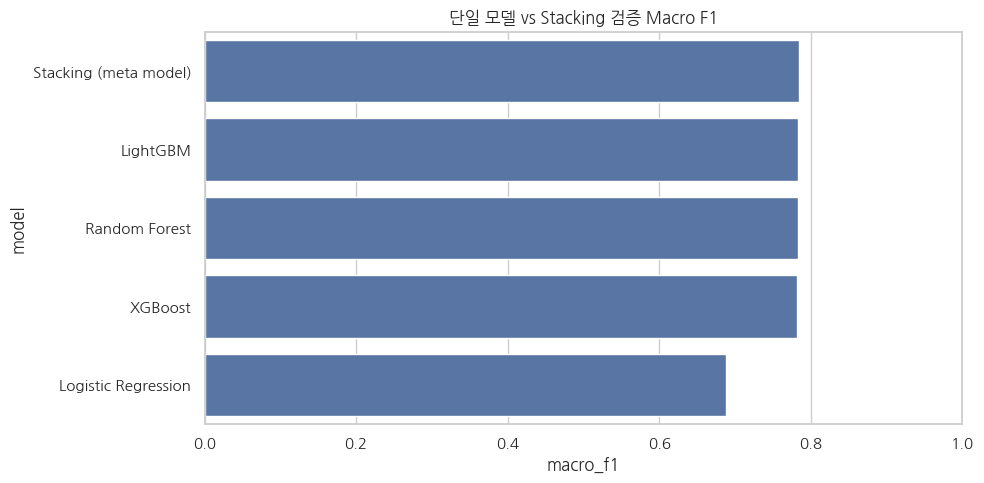

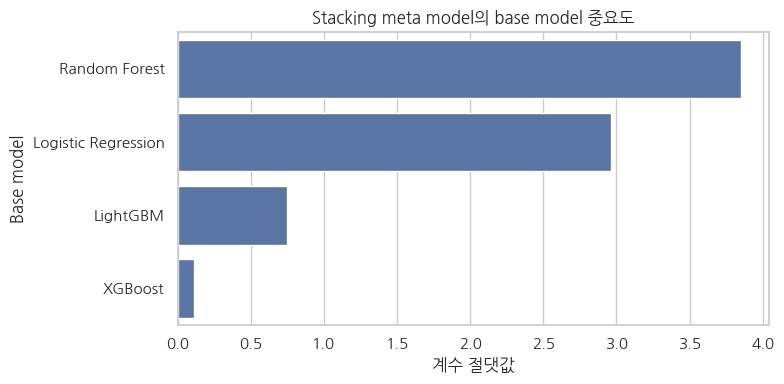

In [21]:
# 단일 모델들과 stacking meta model을 같은 validation 기준으로 비교한다.
stacking_metrics = {
    'model': 'Stacking (meta model)',
    'accuracy': accuracy_score(y_valid, stacking_valid_pred),
    'macro_f1': f1_score(y_valid, stacking_valid_pred, average='macro'),
    'roc_auc': roc_auc_score(y_valid, stacking_valid_proba),
}
model_selection_df = pd.concat([
    summary_df[['model', 'accuracy', 'macro_f1', 'roc_auc']],
    pd.DataFrame([stacking_metrics]),
], ignore_index=True).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(model_selection_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=model_selection_df, x='macro_f1', y='model', ax=ax)
ax.set_title('단일 모델 vs Stacking 검증 Macro F1')
ax.set_xlim(0, 1)
plt.tight_layout()

# meta model 계수 절댓값으로 base model별 중요도를 확인한다.
meta_importance_df = pd.DataFrame({
    'base_model': list(baseline_models.keys()),
    'coefficient': meta_model.coef_[0],
})
meta_importance_df['importance'] = meta_importance_df['coefficient'].abs()
meta_importance_df = meta_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
display(meta_importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=meta_importance_df, x='importance', y='base_model', ax=ax)
ax.set_title('Stacking meta model의 base model 중요도')
ax.set_xlabel('계수 절댓값')
ax.set_ylabel('Base model')
plt.tight_layout()

## Stacking 기준 Threshold 튜닝

In [27]:
# threshold는 선택된 stacking meta model의 validation 예측 확률을 기준으로 탐색한다.
threshold_df = find_best_threshold(y_valid, stacking_valid_proba)
display(threshold_df.head(10))

optimal_threshold = threshold_df.loc[0, 'threshold']

# 실제 후속 분석에 적용할 threshold이다. 자동 최적값을 쓰려면 아래 값을 optimal_threshold로 바꾼다.
best_threshold = 0.32
threshold_pred = (stacking_valid_proba >= best_threshold).astype(int)

print(f'validation 기준 최적 threshold: {optimal_threshold:.2f}')
print(f'현재 적용 threshold: {best_threshold:.2f}')

evaluate_predictions(
    f'Stacking meta model threshold={best_threshold:.2f}',
    y_valid,
    threshold_pred,
    stacking_valid_proba,
)

,threshold,macro_f1
0,0.32,0.802062
1,0.33,0.801467
2,0.29,0.801296
3,0.35,0.800810
4,0.36,0.800703
5,0.38,0.800591
6,0.31,0.800566
7,0.34,0.800358
8,0.37,0.800135
9,0.28,0.799351


validation 기준 최적 threshold: 0.32
현재 적용 threshold: 0.32
[Stacking meta model threshold=0.32] 검증 성능
Accuracy : 0.9591
Macro F1 : 0.8021
ROC AUC  : 0.8842

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5880
           1       0.72      0.55      0.63       386

    accuracy                           0.96      6266
   macro avg       0.84      0.77      0.80      6266
weighted avg       0.96      0.96      0.96      6266

Confusion matrix
[[5796   84]
 [ 172  214]]


In [28]:
def get_feature_names(fitted_pipeline):
    # Pipeline 내부 전처리 후 생성된 최종 feature 이름을 가져온다.
    return fitted_pipeline.named_steps['preprocess'].get_feature_names_out().tolist()


for model_name, fitted in fitted_base_models.items():
    feature_names = get_feature_names(fitted)
    estimator = fitted.named_steps['model']
    if hasattr(estimator, 'feature_importances_'):
        importance = pd.Series(estimator.feature_importances_, index=feature_names).sort_values(ascending=False)
    elif hasattr(estimator, 'coef_'):
        importance = pd.Series(np.abs(estimator.coef_[0]), index=feature_names).sort_values(ascending=False)
    else:
        continue
    print(f'[{model_name}] top 10 features')
    display(importance.head(10).to_frame('importance'))

[Logistic Regression] top 10 features


,importance
cust_payment_terms_NATL,2.350755
cust_payment_terms_NAX2,2.231528
cust_payment_terms_grp_NAX2,2.231528
cust_payment_terms_NA3F,2.123288
cust_payment_terms_grp_NAVR,1.585954
cust_payment_terms_NAVR,1.585954
cust_payment_terms_NAM1,1.517795
cust_payment_terms_grp_NAM1,1.517795
cust_payment_terms_grp_NAAW,1.509301
cust_payment_terms_NAAW,1.509301


[Random Forest] top 10 features


,importance
amount_in_usd,0.078611
late_rate_time_decay_lambda_0_8,0.077624
current_transaction_count,0.077047
cust_allowed_pay_days_late_rate_past,0.069344
sum_outstanding_amount_past,0.059703
ratio_paid_invoices_late_past,0.058577
cleared_count,0.056948
baseline_day,0.048051
recent_20_late_rate,0.045927
recent_10_late_rate,0.035204


[XGBoost] top 10 features


,importance
cust_allowed_pay_days_late_rate_past,0.171884
cust_payment_terms_NAG2,0.087311
cust_payment_terms_NAVF,0.075502
business_code_U001,0.057948
cust_payment_terms_NAX2,0.046536
Allowed_Pay_Days,0.032443
cust_payment_terms_NAA8,0.028114
cust_payment_terms_NAD5,0.024461
cust_payment_terms_NAH4,0.024052
late_rate_time_decay_lambda_0_8,0.020598


[LightGBM] top 10 features


,importance
amount_in_usd,2062
baseline_day,959
sum_outstanding_amount_past,890
current_transaction_count,737
cleared_count,498
baseline_dayofweek,434
avg_days_late_paid_late_past,430
baseline_month,334
cust_allowed_pay_days_late_rate_past,325
Allowed_Pay_Days,274


## Validation 기준 비용-편익 분석

Stacking meta model의 기본 threshold 0.50과 validation에서 튜닝한 threshold를 비교한다. 비용 계산은 validation 데이터만 사용하며, test 데이터는 사용하지 않는다.

In [29]:
# 비용-편익 분석은 validation 원본 데이터와 stacking meta model 예측만 사용한다.
COST_FIXED_FP = 23.0
DEFAULT_THRESHOLD = 0.50


def recovery_cost_per_1000(delay_days):
    # FN은 실제 연체를 놓친 경우로 보고, 연체 기간별 회수 비용을 적용한다.
    if delay_days <= 30:
        return 1.5
    if delay_days <= 60:
        return 5.0
    if delay_days <= 90:
        return 8.0
    return 10.5


def make_validation_cost_frame(pred, pred_proba, scenario):
    # amount_in_usd는 로그 변환 값이므로 실제 금액으로 복원한다.
    frame = valid_raw.copy().reset_index(drop=True)
    frame['y_true'] = y_valid.reset_index(drop=True).values
    frame['y_pred'] = np.asarray(pred).astype(int)
    frame['pred_proba'] = np.asarray(pred_proba)
    frame['scenario'] = scenario
    frame['delay_days'] = frame['business_days_late'].clip(lower=0)
    frame['amount_usd_actual'] = np.expm1(frame['amount_in_usd'])

    frame['is_fn'] = (frame['y_true'] == 1) & (frame['y_pred'] == 0)
    frame['is_fp'] = (frame['y_true'] == 0) & (frame['y_pred'] == 1)
    frame['is_tp'] = (frame['y_true'] == 1) & (frame['y_pred'] == 1)
    frame['is_tn'] = (frame['y_true'] == 0) & (frame['y_pred'] == 0)

    frame['cost_per_1000'] = frame['delay_days'].apply(recovery_cost_per_1000)
    frame['fn_recovery_cost'] = np.where(
        frame['is_fn'],
        frame['amount_usd_actual'] / 1000 * frame['cost_per_1000'],
        0.0,
    )
    frame['fp_fixed_cost'] = np.where(
        frame['is_fp'],
        COST_FIXED_FP,
        0.0,
    )
    frame['total_error_cost'] = frame['fn_recovery_cost'] + frame['fp_fixed_cost']
    return frame


def summarize_cost(frame):
    return {
        'scenario': frame['scenario'].iloc[0],
        'threshold': frame.attrs.get('threshold'),
        'tp': int(frame['is_tp'].sum()),
        'tn': int(frame['is_tn'].sum()),
        'fp': int(frame['is_fp'].sum()),
        'fn': int(frame['is_fn'].sum()),
        'fn_recovery_cost': frame['fn_recovery_cost'].sum(),
        'fp_fixed_cost': frame['fp_fixed_cost'].sum(),
        'total_error_cost': frame['total_error_cost'].sum(),
        'macro_f1': f1_score(frame['y_true'], frame['y_pred'], average='macro'),
        'accuracy': accuracy_score(frame['y_true'], frame['y_pred']),
    }


stacking_default_pred = (stacking_valid_proba >= DEFAULT_THRESHOLD).astype(int)
stacking_tuned_pred = threshold_pred

default_cost_df = make_validation_cost_frame(
    stacking_default_pred,
    stacking_valid_proba,
    f'Stacking threshold={DEFAULT_THRESHOLD:.2f}',
)
default_cost_df.attrs['threshold'] = DEFAULT_THRESHOLD

tuned_cost_df = make_validation_cost_frame(
    stacking_tuned_pred,
    stacking_valid_proba,
    f'Stacking threshold={best_threshold:.2f}',
)
tuned_cost_df.attrs['threshold'] = best_threshold

cost_summary_df = pd.DataFrame([
    summarize_cost(default_cost_df),
    summarize_cost(tuned_cost_df),
])
base_total_cost = cost_summary_df.loc[0, 'total_error_cost']
cost_summary_df['cost_saving_vs_default'] = base_total_cost - cost_summary_df['total_error_cost']
cost_summary_df['cost_saving_rate'] = np.where(
    base_total_cost > 0,
    cost_summary_df['cost_saving_vs_default'] / base_total_cost,
    0.0,
)

cost_display_cols = [
    'scenario', 'threshold', 'accuracy', 'macro_f1', 'tp', 'tn', 'fp', 'fn',
    'fn_recovery_cost', 'fp_fixed_cost', 'total_error_cost',
    'cost_saving_vs_default', 'cost_saving_rate',
]
display(cost_summary_df[cost_display_cols])

,scenario,threshold,accuracy,macro_f1,tp,tn,fp,fn,fn_recovery_cost,fp_fixed_cost,total_error_cost,cost_saving_vs_default,cost_saving_rate
0,Stacking threshold=0.50,0.50,0.959783,0.784216,181,5833,47,205,10073.162236,1081.0,11154.162236,0.000000,0.000000
1,Stacking threshold=0.32,0.32,0.959145,0.802062,214,5796,84,172,8859.554334,1932.0,10791.554334,362.607902,0.032509


튜닝 threshold 적용 후 비용 절감액: $363
튜닝 threshold 적용 후 비용 절감률: 3.25%


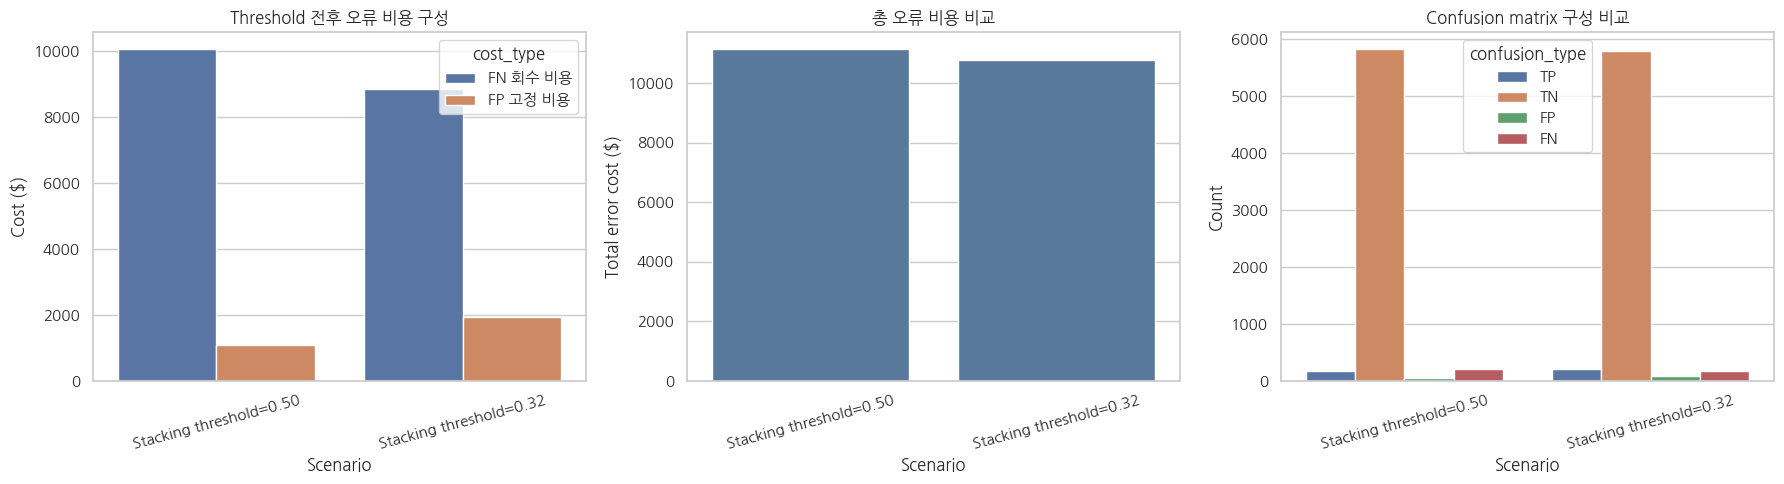

In [30]:
# threshold 튜닝 전후의 오류 비용과 confusion matrix 구성을 함께 시각화한다.
plot_df = cost_summary_df.melt(
    id_vars='scenario',
    value_vars=['fn_recovery_cost', 'fp_fixed_cost'],
    var_name='cost_type',
    value_name='cost',
)
plot_df['cost_type'] = plot_df['cost_type'].map({
    'fn_recovery_cost': 'FN 회수 비용',
    'fp_fixed_cost': 'FP 고정 비용',
})

confusion_plot_df = cost_summary_df.melt(
    id_vars='scenario',
    value_vars=['tp', 'tn', 'fp', 'fn'],
    var_name='confusion_type',
    value_name='count',
)
confusion_plot_df['confusion_type'] = confusion_plot_df['confusion_type'].str.upper()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_df, x='scenario', y='cost', hue='cost_type', ax=axes[0])
axes[0].set_title('Threshold 전후 오류 비용 구성')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('Cost ($)')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=cost_summary_df, x='scenario', y='total_error_cost', ax=axes[1], color='#4C78A8')
axes[1].set_title('총 오류 비용 비교')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Total error cost ($)')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=confusion_plot_df, x='scenario', y='count', hue='confusion_type', ax=axes[2])
axes[2].set_title('Confusion matrix 구성 비교')
axes[2].set_xlabel('Scenario')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()

print(f"튜닝 threshold 적용 후 비용 절감액: ${cost_summary_df.loc[1, 'cost_saving_vs_default']:,.0f}")
print(f"튜닝 threshold 적용 후 비용 절감률: {cost_summary_df.loc[1, 'cost_saving_rate']:.2%}")

In [26]:
# 모델을 사용하지 않는 경우 validation 지연 매출채권 전체에 드는 회수 비용을 계산한다.
baseline_cost_df = valid_raw.copy().reset_index(drop=True)
baseline_cost_df['y_true'] = y_valid.reset_index(drop=True).values
baseline_cost_df['delay_days'] = baseline_cost_df['business_days_late'].clip(lower=0)
baseline_cost_df['amount_usd_actual'] = np.expm1(baseline_cost_df['amount_in_usd'])

# 실제 지연 건(target=1)만 회수 대상이라고 보고 비용을 합산한다.
delayed_df = baseline_cost_df[baseline_cost_df['y_true'] == 1].copy()
delayed_df['cost_per_1000'] = delayed_df['delay_days'].apply(recovery_cost_per_1000)
delayed_df['recovery_cost'] = delayed_df['amount_usd_actual'] / 1000 * delayed_df['cost_per_1000']

baseline_total_cost = delayed_df['recovery_cost'].sum()
tuned_total_error_cost = cost_summary_df.loc[
    cost_summary_df['threshold'].eq(best_threshold),
    'total_error_cost',
].iloc[0]

print(f"validation 지연 매출채권 건수(target=1): {len(delayed_df):,}")
display(delayed_df[[
    'cust_number', 'amount_usd_actual', 'delay_days', 'cost_per_1000', 'recovery_cost',
]].head())
print(f"모델 없음(지연 매출채권 전체) 총 회수 비용: ${baseline_total_cost:,.0f}")
print(f"Stacking tuned threshold 총 오류 비용: ${tuned_total_error_cost:,.0f}")
print(f"모델 적용 시 비용 차이: ${baseline_total_cost - tuned_total_error_cost:,.0f}")


validation 지연 매출채권 건수(target=1): 386


,cust_number,amount_usd_actual,delay_days,cost_per_1000,recovery_cost
14,0140106408,55866.6450,7,1.5,83.799967
18,CCU013,334.5000,34,5.0,1.672500
24,CCU013,1090.7700,34,5.0,5.453850
85,0140106408,48314.9475,7,1.5,72.472421
96,0140106408,85827.7500,7,1.5,128.741625


모델 없음(지연 매출채권 전체) 총 회수 비용: $18,335
Stacking tuned threshold 총 오류 비용: $10,944
모델 적용 시 비용 차이: $7,390
